In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
csv_path = "../../../daos-benchmarking/ior_results/ior_rw.csv"
full = pd.read_csv(csv_path, index_col=0)

# Filter: xfer 2M and 16M, ppn 8/16/32/48
ppn_list  = [8, 16, 32, 48]
xfer_list = ["2M", "16M"]

df = full[
    full["xfer_str"].isin(xfer_list) &
    full["tasks_per_node"].isin(ppn_list)
].copy()

df["tasks_per_node"] = df["tasks_per_node"].astype(int)

In [3]:
# --- Statistics ---
config_cols = ["nnodes", "tasks_per_node", "xfer_str", "access"]

counts = df.groupby(config_cols).size().rename("times_tested")
unique_configs = len(counts)

print(f"Unique configurations tested : {unique_configs}")
print(f"Total rows (filtered df)     : {len(df)}")
print()
print("Times each configuration was tested:")
print(counts.to_string())


Unique configurations tested : 96
Total rows (filtered df)     : 96

Times each configuration was tested:
nnodes  tasks_per_node  xfer_str  access
1       8               16M       read      1
                                  write     1
                        2M        read      1
                                  write     1
        16              16M       read      1
                                  write     1
                        2M        read      1
                                  write     1
        32              16M       read      1
                                  write     1
                        2M        read      1
                                  write     1
        48              16M       read      1
                                  write     1
                        2M        read      1
                                  write     1
2       8               16M       read      1
                                  write     1
                        2

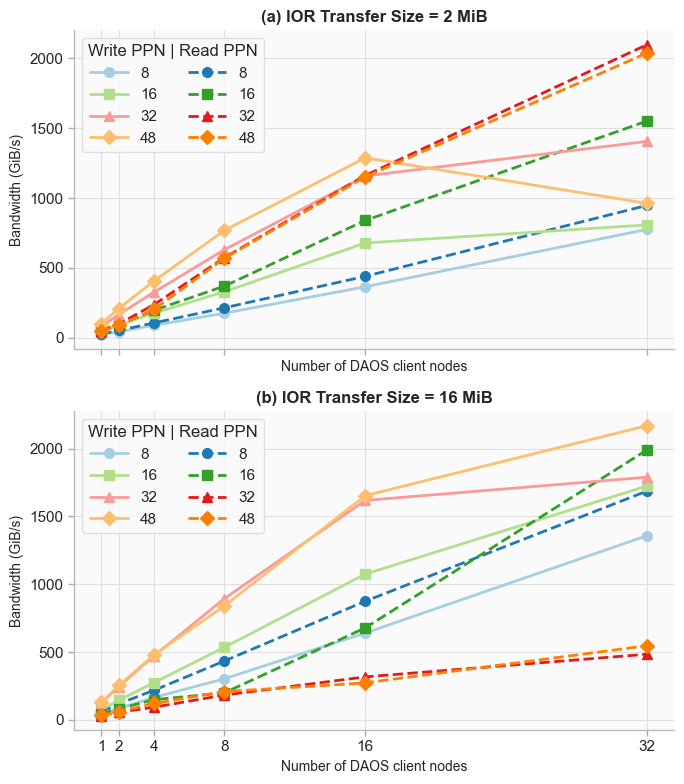

In [9]:
sns.set_theme(style="ticks")
mpl.rcParams.update({
    "axes.spines.top":        False,
    "axes.spines.right":      False,
    "axes.grid":              True,
    "grid.color":             "#e0e0e0",
    "grid.linewidth":         0.8,
    "axes.facecolor":         "#fafafa",
    "figure.facecolor":       "white",
    "font.size":              12,
    "axes.titlesize":         12,
    "axes.labelsize":         10,
    "xtick.labelsize":        11,
    "ytick.labelsize":        11,
    "legend.fontsize":        11,
    "legend.title_fontsize":  12,
    "lines.linewidth":        2,
})

# Paired colors: light shade -> write, dark shade -> read, one pair per ppn
paired = sns.color_palette("Paired", 12)
palette = {}
for i, p in enumerate(ppn_list):
    palette[("write", p)] = paired[i * 2]
    palette[("read",  p)] = paired[i * 2 + 1]

node_ticks = sorted(df["nnodes"].unique())
marker_cycle = ["o", "s", "^", "D"]
subtitles = ["(a)", "(b)"]

fig, axes = plt.subplots(2, 1, figsize=(7, 8), sharex=True)

for idx, (xfer, ax) in enumerate(zip(xfer_list, axes)):
    xdf = df[df["xfer_str"] == xfer]
    line_map = {}

    for j, p in enumerate(ppn_list):
        for access, ls in [("write", "-"), ("read", "--")]:
            sub = xdf[(xdf["tasks_per_node"] == p) & (xdf["access"] == access)].sort_values("nnodes")
            if sub.empty:
                continue
            label = f"{access}-{p}"
            line, = ax.plot(
                sub["nnodes"], sub["bw(GiB/s)"],
                label=label,
                color=palette[(access, p)],
                marker=marker_cycle[j % 4],
                linestyle=ls,
                markersize=7,
            )
            line_map[label] = line

    ax.set_xticks(node_ticks)
    ax.set_ylabel("Bandwidth (GiB/s)")
    ax.set_title(f"{subtitles[idx]} IOR Transfer Size = {xfer.replace('M', ' MiB')}", fontweight="bold", loc="center")
    ax.set_xlabel("Number of DAOS client nodes")

    ax.tick_params(axis="both", length=4, color="#aaaaaa", width=1)
    for spine in ax.spines.values():
        spine.set_color("#bbbbbb")
        spine.set_linewidth(1)

    # Left col = write, right col = read
    legend_order = [f"write-{p}" for p in ppn_list] + [f"read-{p}" for p in ppn_list]
    handles = [line_map[l] for l in legend_order if l in line_map]
    labels  = [k.split("-")[1] for k in legend_order if k in line_map]

    ax.legend(
        handles, labels,
        title="Write PPN | Read PPN",
        loc="upper left",
        frameon=True,
        framealpha=0.9,
        edgecolor="#dddddd",
        ncol=2,
        handlelength=2.5,
    )



fig.tight_layout(h_pad=1)
plt.savefig("ior_rw_bw.pdf", bbox_inches="tight")
plt.show()
